In [123]:
import pytorch3d.structures
import pytorch3d.io
import pytorch3d.renderer
import pytorch3d.renderer.cameras
import torch
import numpy
import imageio
from matplotlib import pyplot as plt
import pickle

In [124]:
file = open("data/rgbd_data.pkl", "rb")
obj = pickle.load(file)
file.close()

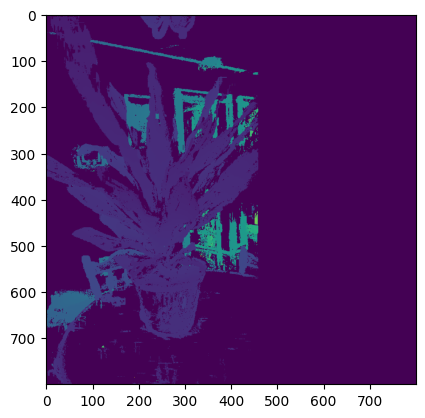

In [156]:
cameras1 = obj['cameras2']
depth = torch.Tensor(obj['depth2'] / (obj['depth2'].max() - obj['depth2'].min()) )
points1 = cameras1.unproject_points(depth, world_coordinates=True)
plt.imshow(depth)

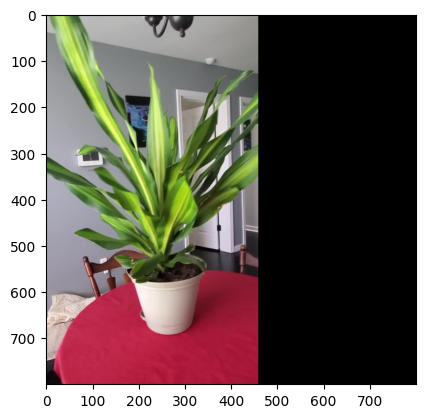

In [157]:
plt.plot(figsize=(10, 10))

plt.imshow(obj['rgb2'])

In [158]:
rgb = torch.Tensor( numpy.ones_like(points1.numpy()) )
pointcloud = pytorch3d.structures.Pointclouds(points=[points1], features=[rgb])


In [159]:
renderer = pytorch3d.renderer.PointsRenderer(
    rasterizer = pytorch3d.renderer.PointsRasterizer(
        cameras=cameras1
    ),
    compositor = pytorch3d.renderer.AlphaCompositor()
)

In [160]:
rend = renderer(pointcloud, cameras=cameras1)

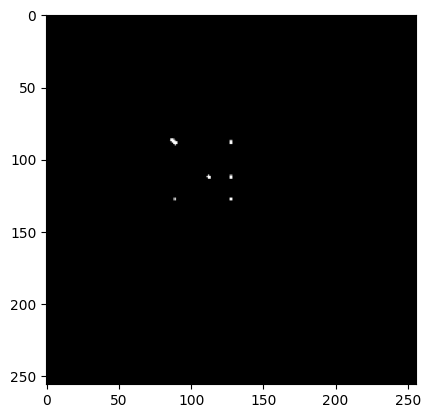

In [161]:
plt.plot(figsize=(10,10))
plt.imshow(rend[0, ..., :3].numpy())

In [162]:
obj

{'rgb1': array([[[0.81960785, 0.8039216 , 0.80784315],
         [0.81960785, 0.8039216 , 0.80784315],
         [0.8187211 , 0.8030349 , 0.8069564 ],
         ...,
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ]],
 
        [[0.81960785, 0.8039216 , 0.80784315],
         [0.81960785, 0.8039215 , 0.80784315],
         [0.8182827 , 0.80259645, 0.806518  ],
         ...,
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ]],
 
        [[0.81828433, 0.802598  , 0.8065196 ],
         [0.8196078 , 0.8039216 , 0.80784315],
         [0.8174043 , 0.80171794, 0.80563956],
         ...,
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ]],
 
        ...,
 
        [[0.6610104 , 0.20610838, 0.2806182 ],
         [0.6588363 , 0.20393431,

In [163]:
points1.shape, rgb.shape

(torch.Size([800, 3]), torch.Size([800, 3]))

In [165]:
print(depth.min())

tensor(0.)


In [167]:
points1.shape, depth.shape

(torch.Size([800, 3]), torch.Size([800, 800]))

In [172]:
pointcloud.points_list()[0].shape

torch.Size([800, 3])

In [175]:
!pip install omegaconf

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for antlr4-python3-runtime: filename=antlr4_python3_runtime-4.9.3-py3-none-any.whl size=144590 sha256=c024a737a21283302afeaeb9654130efaac11b9ce490472bb17df39e6abd7d07
  Stored in directory: /home/huyn/.cache/pip/wheels/12/93/dd/1f6a127edc45659556564c5730f6d4e300888f4bca2d4c5a88
Successfully built antlr4-python3-runtime
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [omegaconf]


In [210]:
# Restack image tensor to 3,H,W
obj['rgb2']
rgb_restacked = torch.Tensor([obj['rgb2'][:, :, 0], obj['rgb2'][:, :, 1], obj['rgb2'][:, :, 2]])

from pytorch3d.implicitron.models.model_dbir import get_rgbd_point_cloud
batch_cam = obj['cameras2']
batch_img_rgb = rgb_restacked.unsqueeze(0)
batch_depth = torch.Tensor(obj['depth2']).unsqueeze(0).unsqueeze(0)

point_cloud = get_rgbd_point_cloud(batch_cam, batch_img_rgb, batch_depth)

In [211]:
rend = renderer(point_cloud, cameras=obj['cameras2'])

In [ ]:
plt.plot(fig)